# priya_loader — quick start

`priya_loader` reads the on-disk outputs of the PRIYA simulation suite
([Bird et al. 2023](https://arxiv.org/abs/2306.05471)) and returns them as numpy
arrays. There are two products per simulation:

- the **initial-condition density**, an MP-GenIC `bigfile` directory, and
- the **Lyman-α optical depth** `τ` at each output redshift, a `fake_spectra` HDF5
  file (the flux is `F = exp(−τ)`).

The top-level object is `PriyaDataset`: it iterates over `(simulation, redshift)`
and returns `Sample(params, redshift, ic, tau)` (`.as_tuple()` for the bare tuple).
Each section below shows the loader call, what it does to the raw files underneath,
and the array it returns.

Paths are arguments, not hard-coded. This notebook defaults to the NERSC PRIYA path;
set `$PRIYA_ROOT` (or edit the `ROOT` cell) to point elsewhere. Upstream conventions
(unit system, the `τ` HDF5 key, the axis mapping, the `ICDensity` semantics) are
pinned to exact git commits in [`PROVENANCE.md`](../PROVENANCE.md).

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import priya_loader as pl
from priya_loader import (
    discover_simulations, SimParams, load_tau_grid, load_ic_density, PriyaDataset,
)

ROOT = os.environ.get(
    "PRIYA_ROOT",
    "/global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full",
)
print("priya_loader", pl.__version__, "| ROOT:", ROOT, "| exists:", Path(ROOT).is_dir())

priya_loader 0.2.0.dev0 | ROOT: /global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full | exists: True


## 1. Finding simulations and reading parameters

`discover_simulations(ROOT)` returns one entry per simulation folder under `ROOT` (a
folder qualifies if it contains a `SimulationICs.json`). `SimParams.from_dir(folder)`
parses the parameters out of the folder name and takes the box size and particle
count from the run config (`_genic_params.ini` / `mpgadget.param`) rather than the
`SimulationICs.json`, whose `box`/`npart` are unreliable (see `PROVENANCE.md`).

The nine PRIYA parameters (`SimParams` exposes each individually; the table below
groups them by theme, but the on-disk folder name concatenates them in the order
`ns, Ap, herei, heref, alphaq, hub, omegamh2, hireionz, bhfeedback`. Ranges are
measured across the staged `emu_full` folders (as in the README):

| parameter | folder key | what it is | range (staged suite) |
|---|---|---|---|
| `n_s` | `ns` | scalar spectral index | 0.80 – 1.04 |
| `A_p` | `Ap` | primordial amplitude at `k = 2π/8 ≈ 0.78 Mpc⁻¹` (the 8 Mpc scale) | 1.2 – 2.6 ×10⁻⁹ |
| `Ω_m h²` | `omegamh2` | physical matter density | 0.140 – 0.146 |
| `h` | `hub` | Hubble parameter | 0.65 – 0.75 |
| `z_HeII,i` | `herei` | He II reionization start redshift | 3.5 – 4.5 |
| `z_HeII,f` | `heref` | He II reionization end redshift | 2.2 – 3.2 |
| `α_q` | `alphaq` | quasar (He II–ionizing) spectral index | 1.3 – 3.0 |
| `z_HI` | `hireionz` | H I reionization median redshift | 6.5 – 8.0 |
| `ε_AGN` | `bhfeedback` | AGN feedback thermal efficiency | 0.031 – 0.069 |

`A_p` is the folder-name amplitude at PRIYA's pivot (`k = 2π/8`); it is *not* the
`scalar_amp` (= `A_s` at `k = 0.05 Mpc⁻¹`) stored in the config — the two differ by
`((2π/8)/0.05)**(n_s−1)`. (The emulator also carries two mean-flux nuisances, `τ₀` and
`dτ₀`, applied to the flux in post-processing — not simulation inputs, so not listed
here.) `SimParams.from_dir(...).name_params` is the parsed dict.

60 simulations under ROOT

sims[0] parameters:
    ns           = 0.803
    Ap           = 2.2e-09
    herei        = 4.05
    heref        = 2.67
    alphaq       = 2.21
    hub          = 0.735
    omegamh2     = 0.141
    hireionz     = 7.17
    bhfeedback   = 0.056
    box=120.0 Mpc/h  npart=1536 (lowres)  z: 99.0 -> 2.0



read parameters for 60 / 60 sims


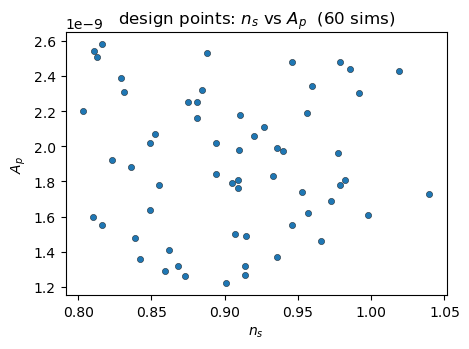

In [2]:
sims = discover_simulations(ROOT)
print(len(sims), "simulations under ROOT\n")

p0 = SimParams.from_dir(sims[0].directory)
print("sims[0] parameters:")
for key in ("ns", "Ap", "herei", "heref", "alphaq", "hub", "omegamh2", "hireionz", "bhfeedback"):  # on-disk order
    print(f"    {key:12s} = {p0.name_params[key]}")
print(f"    box={p0.box} Mpc/h  npart={p0.npart} ({p0.fidelity})  z: {p0.z_init} -> {p0.z_end}")

# scatter n_s vs A_p over the whole suite (the emulator design points)
ns, Ap = [], []
for s in sims:
    try:
        p = SimParams.from_dir(s.directory)
        ns.append(p.ns); Ap.append(float(p.name_params["Ap"]))
    except Exception:
        pass
print("\nread parameters for", len(ns), "/", len(sims), "sims")

plt.figure(figsize=(4.8, 3.6))
plt.scatter(ns, Ap, s=20, c="C0", edgecolors="k", linewidths=0.3)
plt.xlabel(r"$n_s$"); plt.ylabel(r"$A_p$")
plt.title(f"design points: $n_s$ vs $A_p$  ({len(ns)} sims)")
plt.tight_layout(); plt.show()

## 2. Optical depth `τ`

`load_tau_grid(path, axis)` returns `τ` for one line-of-sight axis. Underneath it is a
thin `h5py` read. `fake_spectra` stores every sightline in a single dataset,
`tau/H/1/1215` (H I, Lyα 1215 Å), of shape `(Nlos, Npix)` with `Nlos = 3·ngrid²` —
`ngrid²` skewers down each of the three box axes, concatenated. `load_tau_grid` opens
the file, slices the `ngrid²`-row block belonging to the axis you ask for, and reshapes
that block to `(ngrid, ngrid, nbins)`. Nothing is rebinned; the values are the stored
`float32` optical depths.

To show there is nothing hidden in the wrapper, read the file directly with `h5py` first:

In [3]:
import h5py

sim = sims[0]
fpath = sorted((Path(ROOT) / sim.directory.name / "output").glob("SPECTRA_*"))[0] / "lya_forest_spectra_grid_480.hdf5"

with h5py.File(fpath, "r") as f:
    print("top-level groups :", list(f.keys()))
    dset = f["tau/H/1/1215"]                       # this is what load_tau_grid reads
    nlos, npix = dset.shape
    print("tau/H/1/1215     :", dset.shape, dset.dtype, " = (Nlos, Npix)")
    print("Nlos = 3*ngrid^2  -> ngrid =", int(round((nlos / 3) ** 0.5)))
    print("Header.redshift  :", float(f["Header"].attrs["redshift"]))

top-level groups : ['Header', 'colden', 'density_weight_density', 'num_important', 'spectra', 'tau', 'tau_obs', 'temperature', 'velocity']
tau/H/1/1215     : (691200, 1556) float32  = (Nlos, Npix)
Nlos = 3*ngrid^2  -> ngrid = 480
Header.redshift  : 5.4


`load_tau_grid` does exactly that read, plus the block-slice and reshape, and
attaches the header metadata to the returned object (`.redshift`, `.box`, `.cube_axes`,
`.nbins`, …). `F = exp(−τ)` is the transmitted flux.

g.tau: (480, 480, 1556) = (ngrid, ngrid, nbins)   z = 5.4  cube_axes = ('x', 'y', 'z')


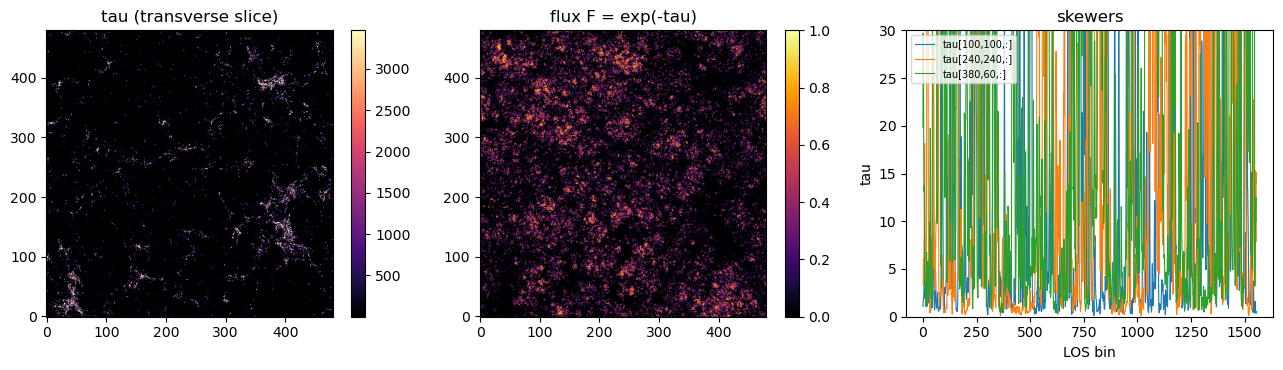

In [4]:
g = load_tau_grid(fpath, axis=3)                # slice the axis-3 block, reshape
print("g.tau:", g.tau.shape, "= (ngrid, ngrid, nbins)   z =", g.redshift, " cube_axes =", g.cube_axes)

b = g.nbins // 2
tau_sl = g.tau[:, :, b]; flux_sl = np.exp(-tau_sl)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
im0 = ax[0].imshow(tau_sl, origin="lower", cmap="magma", vmax=np.percentile(tau_sl, 99))
ax[0].set_title("tau (transverse slice)"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(flux_sl, origin="lower", cmap="inferno", vmin=0, vmax=1)
ax[1].set_title("flux F = exp(-tau)"); fig.colorbar(im1, ax=ax[1])
for (i, j) in [(100, 100), (240, 240), (380, 60)]:
    ax[2].plot(g.tau[i, j, :], lw=0.8, label=f"tau[{i},{j},:]")
ax[2].set_title("skewers"); ax[2].set_xlabel("LOS bin"); ax[2].set_ylabel("tau")
ax[2].set_ylim(0, 30); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()
del g, tau_sl, flux_sl

### The `axis` argument, and what "line of sight" means

A skewer is a mock spectrum sampled along a straight line through the box. The `axis`
argument picks which box direction that line runs along: **`axis=1` → x, `2` → y,
`3` → z**. These are `fake_spectra`'s own labels for the three directions, numbered
**1, 2, 3 — not 0, 1, 2**. So `axis` is a *direction selector*, not a Python array
index; `axis=1` has nothing to do with numpy's axis `0`.

"Line of sight = x" (for `axis=1`) means the sightline points along the box x-axis: you
move along x with `(y, z)` held fixed, and the pixels of the spectrum run along x. In
the returned `(ngrid, ngrid, nbins)` cube, the **last** index runs along that line of
sight; the **first two** index the transverse plane. Because the line-of-sight
coordinate is the one turned into pixels, the two transverse coordinates differ per
axis. `fake_spectra` sets this mapping (`griddedspectra.py` lines 42–60, commit
`93d0e50`, tag `v2.2.3`), and `load_tau_grid` records it as `.cube_axes`:

| `axis` | skewers run along… | `.cube_axes` = (index-0 coord, index-1 coord, LOS coord) |
|:--:|:--:|:--:|
| 1 | x | (y, z, x) |
| 2 | y | (x, z, y) |
| 3 | z | (x, y, z) |

So `g.tau[i, j, :]` is one skewer: for `axis=3` the transverse position `(i, j)` is
`(x, y)` and the pixels run along z; for `axis=1` the same `(i, j)` is `(y, z)` and the
pixels run along x. The two cells below show the mean-flux map from each axis, then the
*same* index `(120, 200)` read on each axis — three different sightlines.

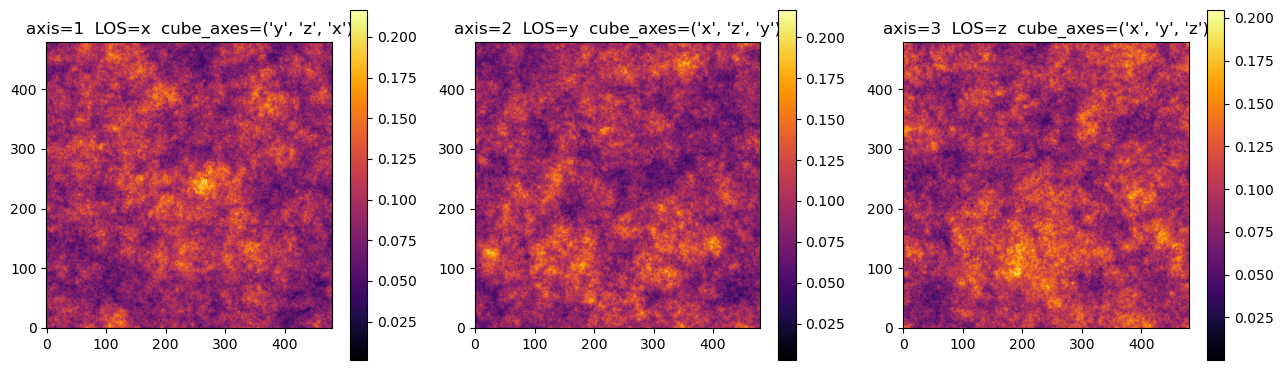

In [5]:
# mean flux down each axis' LOS (each grid loaded, used, and freed in turn)
skewers = {}
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for n, axis in enumerate((1, 2, 3)):
    ga = load_tau_grid(fpath, axis=axis)
    skewers[axis] = (ga.tau[120, 200, :].copy(), tuple(ga.cube_axes))
    im = ax[n].imshow(np.exp(-ga.tau).mean(axis=2), origin="lower", cmap="inferno")
    ax[n].set_title(f"axis={axis}  LOS={'xyz'[axis - 1]}  cube_axes={tuple(ga.cube_axes)}")
    fig.colorbar(im, ax=ax[n]); del ga
plt.tight_layout(); plt.show()

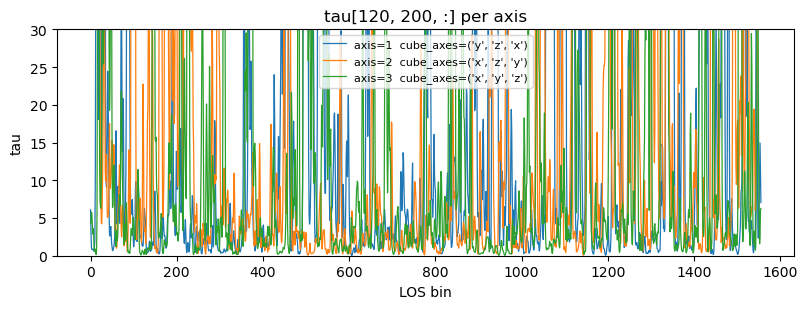

In [6]:
# the same (i, j) = (120, 200) is a different sightline on each axis
plt.figure(figsize=(8.2, 3.2))
for axis in (1, 2, 3):
    tau_skewer, ca = skewers[axis]
    plt.plot(tau_skewer, lw=0.9, label=f"axis={axis}  cube_axes={ca}")
plt.title("tau[120, 200, :] per axis"); plt.xlabel("LOS bin"); plt.ylabel("tau")
plt.ylim(0, 30); plt.legend(fontsize=8); plt.tight_layout(); plt.show()
del skewers

## 3. Initial-condition density

The IC is an MP-GenIC `bigfile` directory. Per particle type — DM under `1/`, gas under
`0/` — it stores four columns: `Position`, `Velocity`, `ICDensity`, `ID`. Read the
directory with `bigfile` to see them:

In [7]:
import bigfile

ICDIR = Path(ROOT) / sim.directory.name / "ICS" / "120_512_99"   # the 512^3 companion (production is 1536^3)
with bigfile.File(str(ICDIR)) as bf:
    print("blocks:", sorted(b for b in bf.blocks))
    pos = bf["1/Position"]; icd = bf["1/ICDensity"]
    print("1/Position :", pos.dtype, pos.size, "rows  (comoving kpc/h, displaced positions)")
    print("1/ICDensity:", icd.dtype, icd.size, "rows  (linear delta_1, one scalar per particle)")

blocks: ['0/ICDensity', '0/ID', '0/Position', '0/Velocity', '1/ICDensity', '1/ID', '1/Position', '1/Velocity', 'Header', 'ICPower', 'ICTransfers']
1/Position : ('<f8', (3,)) 134217728 rows  (comoving kpc/h, displaced positions)
1/ICDensity: float32 134217728 rows  (linear delta_1, one scalar per particle)


`load_ic_density(ic_dir, field=...)` builds an `nmesh³` grid from **one of these
columns**, and the two `field=` values are different reads that give different fields:

- **`field="icdensity"`** reads the **`ICDensity`** column — the linear density
  MP-GenIC computed and stored for each particle at its starting (grid) position —
  together with `ID`, and places each value back on an `nmesh³` grid using `(ID−1)` as
  the grid index (block-averaging when `nmesh < ngrid`). It does not touch `Position`
  and does no painting. This is the linear field `δ₁`.
- **`field="cic"`** reads the **`Position`** column — where the particle sits after
  MP-GenIC has displaced it — and cloud-in-cell paints those positions onto an `nmesh³`
  mesh, returning `ρ/⟨ρ⟩ − 1`. This is the density of the displaced particles.

So `icdensity` is the stored linear field on the grid; `cic` is a density painted from
the moved particles. They are not the same array and are not computed the same way.
(If you want to mesh the particles yourself, `load_ic_particles(ic_dir)` returns the
raw columns.) For `icdensity`, `nmesh` should divide `ngrid`; the staged IC is `512³`,
so `nmesh=256`. The two fields trace the same structure — the displacements at `z≈99`
are small — which is a useful check that the `ID`→grid mapping is correct.

icdensity delta_1: (256, 256, 256)  std 0.055
cic       density: (256, 256, 256)  std 0.050


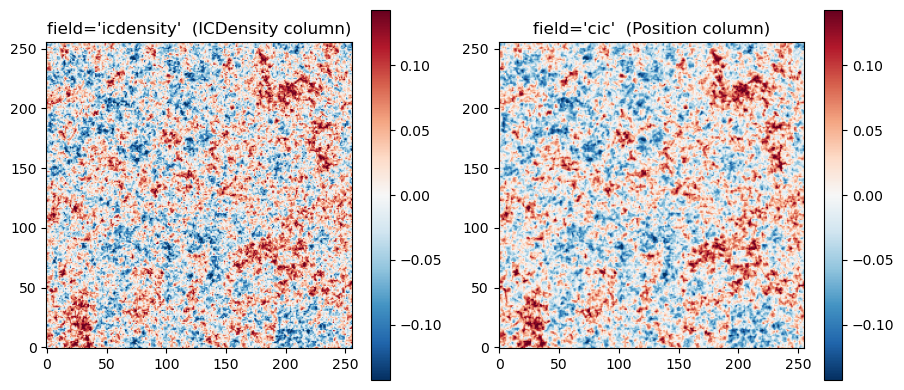

correlation of the two fields:  r = 0.8674


In [8]:
lin = load_ic_density(ICDIR, ptype="dm", nmesh=256, field="icdensity")  # reads ICDensity + ID
cic = load_ic_density(ICDIR, ptype="dm", nmesh=256, field="cic")        # reads Position, CIC paints
print("icdensity delta_1:", lin.delta.shape, " std %.3f" % lin.delta.std())
print("cic       density:", cic.delta.shape, " std %.3f" % cic.delta.std())

k = lin.delta.shape[2] // 2
v = float(np.percentile(np.abs(lin.delta), 99))
fig, ax = plt.subplots(1, 2, figsize=(9.2, 4.0))
im0 = ax[0].imshow(lin.delta[:, :, k], origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
ax[0].set_title("field='icdensity'  (ICDensity column)"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(cic.delta[:, :, k], origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
ax[1].set_title("field='cic'  (Position column)"); fig.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

a = (lin.delta - lin.delta.mean()).ravel(); b = (cic.delta - cic.delta.mean()).ravel()
print("correlation of the two fields:  r = %.4f" % float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))))

## 4. `PriyaDataset`: the whole suite as an iterator

`PriyaDataset(ROOT, ...)` wraps §1–§3 into one iterator. Iterating yields a `Sample` per
`(simulation, redshift)`: for each it calls `load_tau_grid` (with `flux_axis`) and, when
`load_ic=True`, `load_ic_density` (with `ic_field` / `ic_nmesh`), and returns
`Sample(params, redshift, ic, tau)`. One record looks like this:

In [9]:
import warnings
ds = PriyaDataset(ROOT, ic_field="icdensity", ic_nmesh=256, flux_axis=3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    s = next(iter(ds))
print("one Sample:")
print("  params.name  :", s.params.name[:44], "...")
print("  params.ns    :", s.params.ns, "  name_params['Ap'] :", s.params.name_params["Ap"])
print("  redshift     :", s.redshift)
print("  ic           :", None if s.ic is None else s.ic.shape, "(production 1536^3 IC not staged -> None)")
print("  tau          :", None if s.tau is None else s.tau.shape)
print("  as_tuple     :", len(s.as_tuple()), "-> (params, redshift, ic, tau)")
del s

one Sample:
  params.name  : ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21 ...
  params.ns    : 0.80325   name_params['Ap'] : 2.2e-09
  redshift     : 5.4
  ic           : None (production 1536^3 IC not staged -> None)
  tau          : (480, 480, 1556)
  as_tuple     : 4 -> (params, redshift, ic, tau)


**Reading multiple redshifts and multiple parameters.** Iterating walks the suite
*simulation by simulation*, and within each simulation *redshift by redshift*. So a run
of consecutive samples is one simulation's redshift series; when it runs out, the next
simulation starts, carrying its own `Sample.params`. To sweep **parameters** you iterate
across simulations (each `Sample.params` is that sim's nine values); to get one
simulation's **redshift** series you take the run of samples sharing `params.name`.

Useful knobs: `load_ic=False` skips IC loading for a fast τ-only pass; `fidelity="lowres"`
(or `"hires"`) filters by resolution; `flux_axis` / `ic_field` / `ic_nmesh` choose what
each `Sample` carries. Below, a fast τ-only pass, stopping once it has crossed from the
first simulation into the second, printing `⟨F⟩ = ⟨exp(−τ)⟩` at each `(sim, z)`:

In [10]:
rows, sims_seen = [], set()
for smp in PriyaDataset(ROOT, flux_axis=3, load_ic=False):        # load_ic=False: tau only, fast
    rows.append((smp.meta["sim"], smp.params.ns, smp.redshift, float(np.exp(-smp.tau).mean())))
    sims_seen.add(smp.meta["sim"])
    if len(sims_seen) >= 2 and len(rows) >= 28:                  # stop after crossing into sim #2
        break

prev = None
for name, ns_, z, mf in rows:
    mark = "   <- next simulation (new parameters)" if (prev is not None and name != prev) else ""
    print(f"{name[:30]:30s}  n_s={ns_:.4f}  z={z:5.2f}  <F>={mf:.3f}{mark}")
    prev = name

ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 5.40  <F>=0.095
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 5.20  <F>=0.120
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 5.00  <F>=0.150
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 4.80  <F>=0.184
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 4.60  <F>=0.223
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 4.40  <F>=0.267
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 4.20  <F>=0.315
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 4.00  <F>=0.370
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 3.80  <F>=0.437
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 3.60  <F>=0.505
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 3.40  <F>=0.568
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 3.20  <F>=0.625
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 3.00  <F>=0.677
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 2.80  <F>=0.721
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 2.60  <F>=0.760
ns0.803Ap2.2e-09herei4.05heref  n_s=0.8033  z= 2.40  <F

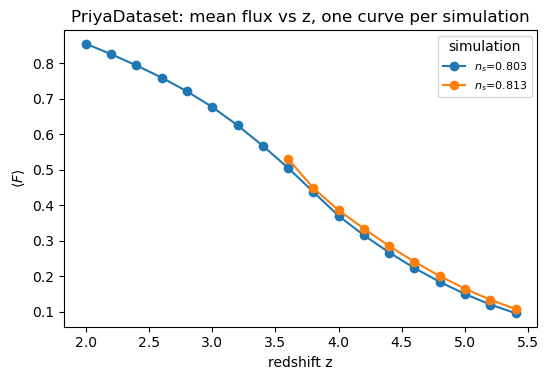

In [11]:
# group those samples by simulation -> one <F>(z) curve per simulation (per parameter set)
curves = {}
for name, ns_, z, mf in rows:
    curves.setdefault((name, ns_), []).append((z, mf))

plt.figure(figsize=(5.6, 3.9))
for (name, ns_), pts in sorted(curves.items(), key=lambda kv: kv[0][1]):
    pts = sorted(pts)
    plt.plot([p[0] for p in pts], [p[1] for p in pts], "o-", label=f"$n_s$={ns_:.3f}")
plt.xlabel("redshift z"); plt.ylabel(r"$\langle F\rangle$")
plt.title("PriyaDataset: mean flux vs z, one curve per simulation")
plt.legend(fontsize=8, title="simulation"); plt.tight_layout(); plt.show()

`ds.export(dir)` writes one `.npz` per `(simulation, redshift)` — the whole suite as
an ML-ready dataset on disk. On this tree `ic` is `None` (the production `1536³` IC is
not staged, only the `512³` companion); read the `512³` field directly as in §3 until it
is.

## 5. Downstream

Turning `δ₁` and `τ` into a flux bias — growth-rescaling `δ₁` from `z≈99` to the flux
redshift, co-registering the cubes with `cube_axes`, deconvolving the mesh window, and
choosing the mean-flux and DLA treatment — is downstream of this loader. The recipe is
in [`HANDOFF.md`](../HANDOFF.md) (following de Belsunce et al. 2025,
[arXiv:2507.00284](https://arxiv.org/abs/2507.00284)). What the loader guarantees is
that the `δ₁` and `τ` it returns share a box, a grid origin, and a transverse
orientation. Note that `τ`'s last axis is a **redshift-space** velocity axis
(`nbins ≠ ngrid`) while `δ₁` is real space, so co-registration still has to resample
the line of sight — again, see `HANDOFF.md`.

## 6. Summary

| call | reads | returns |
|---|---|---|
| `discover_simulations(ROOT)` | folders with `SimulationICs.json` | list of simulations |
| `SimParams.from_dir(dir)` | folder name + run config | the 9 parameters |
| `load_tau_grid(path, axis)` | `tau/H/1/1215` in the HDF5 (h5py) | `(ngrid, ngrid, nbins)` τ cube |
| `load_ic_density(dir, field=)` | `ICDensity`+`ID`, or `Position` | `nmesh³` grid |
| `PriyaDataset(ROOT)` | the above, per `(sim, z)` | `Sample(params, z, ic, tau)`; `.export()` → `.npz` |

Change `ROOT` / `$PRIYA_ROOT` to run against another copy. Upstream conventions are
pinned in [`PROVENANCE.md`](../PROVENANCE.md).